<a href="https://www.kaggle.com/code/antoninast/cat-practice-29-09?scriptVersionId=355843081" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [115]:
from torchvision.datasets import ImageFolder

In [116]:
data_cats = "/kaggle/input/datasets/yapwh1208/cats-breed-dataset/cat_v1"
dataset = ImageFolder(data_cats)

In [117]:
len(dataset)

952

In [118]:
img, label = dataset[700]

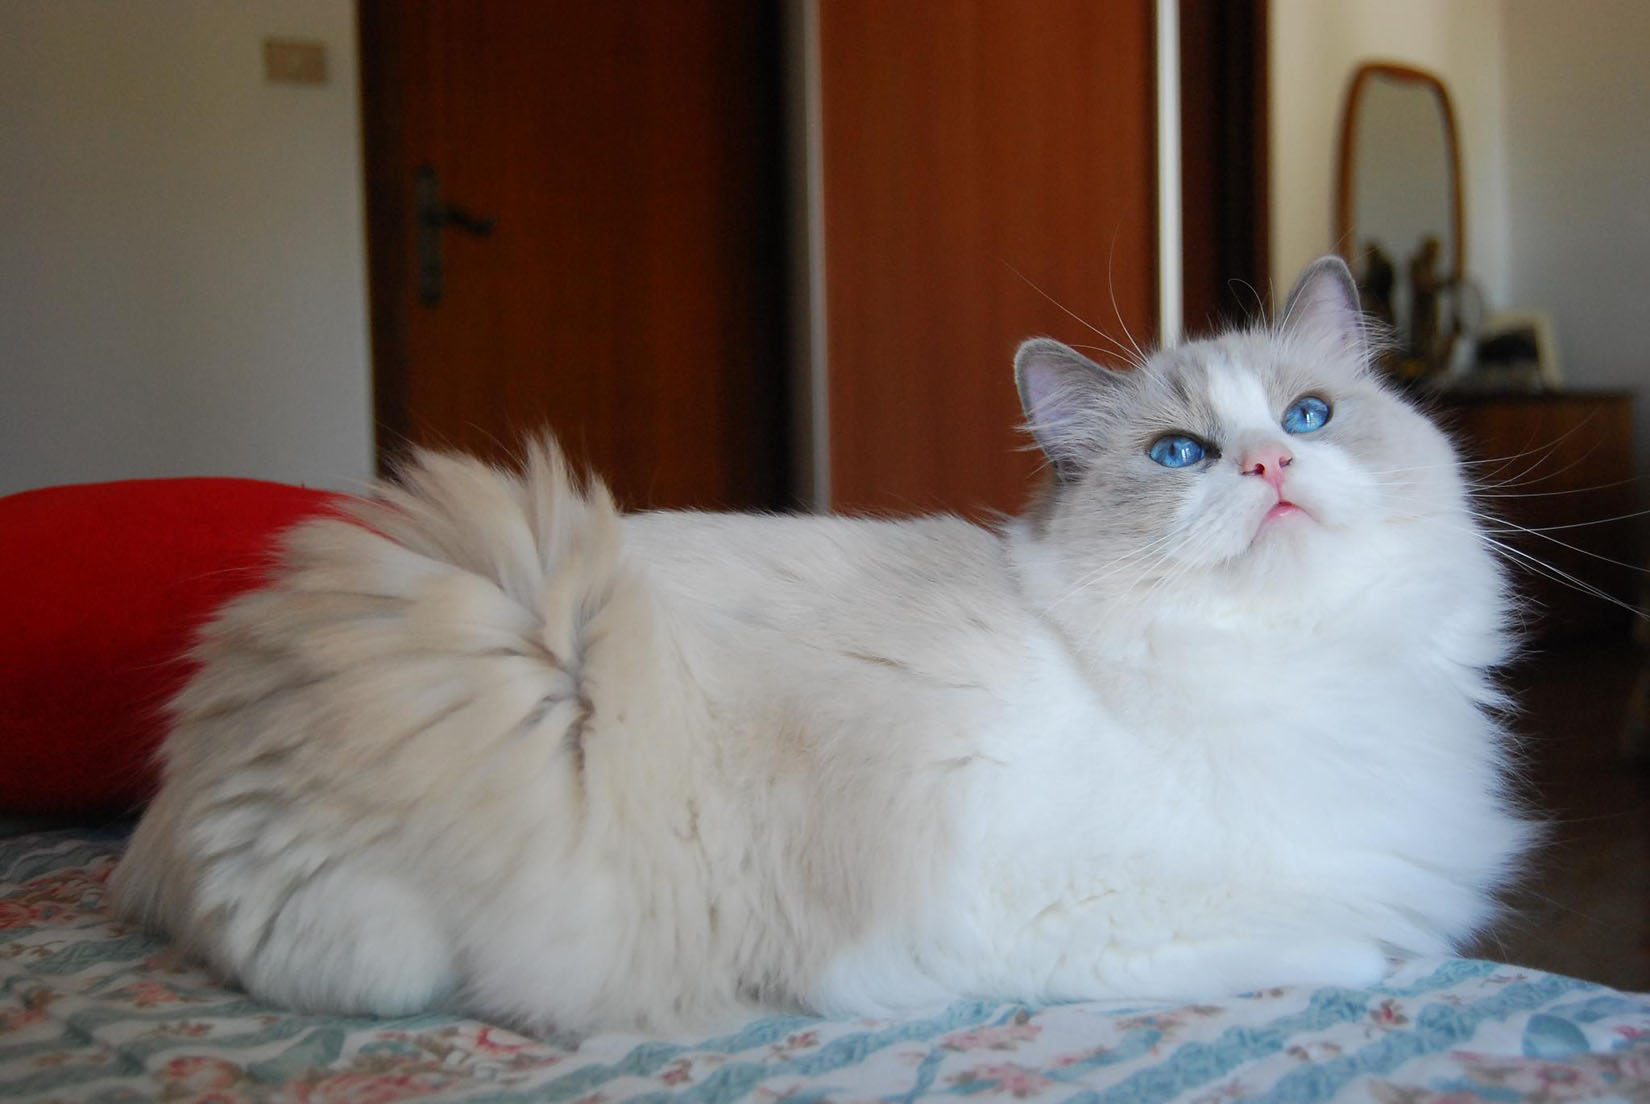

In [119]:
img

In [120]:
dataset.classes

['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']

In [121]:
label

3

In [122]:
from torchvision import transforms

train_transformer = transforms.Compose([
       transforms.Resize([100, 100]), 
       transforms.RandomHorizontalFlip(p=0.5),  
       transforms.RandomRotation(10),   
       transforms.ToTensor()   
])


In [123]:
train_transformer(img)

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

In [124]:
test_transformer = transforms.Compose([
       transforms.Resize([100, 100]),   
       transforms.ToTensor()   
])

In [125]:
from torch.utils.data import random_split
train_dataset, test_dataset = random_split(dataset, [0.8, 0.2])

In [126]:
len(train_dataset)

762

In [127]:
len(test_dataset)

190

In [128]:
train_dataset[1]

(<PIL.Image.Image image mode=RGB size=3264x2448>, 4)

In [129]:
from torch.utils.data import Dataset

In [130]:
class TransformDatasetCats(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [131]:
train_dataset = TransformDatasetCats(train_dataset, train_transformer)
test_dataset = TransformDatasetCats(test_dataset, test_transformer)

In [132]:
train_dataset[0]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 2)

In [133]:
from torch.utils.data import DataLoader

In [134]:
train_loader = DataLoader(train_dataset, batch_size=100)
test_loader = DataLoader(test_dataset, batch_size=100)

In [135]:
for img, labels in train_loader:
    break

In [136]:
labels

tensor([2, 4, 2, 4, 0, 4, 2, 0, 2, 2, 4, 3, 0, 4, 4, 4, 1, 0, 3, 1, 2, 2, 1, 4,
        2, 3, 2, 3, 0, 3, 2, 0, 3, 3, 0, 3, 3, 3, 1, 0, 0, 2, 0, 0, 4, 4, 3, 1,
        1, 3, 3, 4, 2, 3, 1, 1, 3, 1, 3, 0, 4, 2, 0, 3, 2, 4, 4, 0, 3, 3, 2, 0,
        2, 2, 1, 4, 1, 1, 3, 4, 0, 4, 1, 0, 2, 1, 3, 1, 0, 2, 3, 2, 1, 3, 4, 3,
        2, 4, 1, 2])

In [137]:
img.shape

torch.Size([100, 3, 100, 100])

In [138]:
from torch import nn

In [139]:
dataset.classes

['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']

In [140]:
from torch import nn

model = nn.Sequential(
    nn.Conv2d(kernel_size=3, padding='same', out_channels=10, in_channels=3),  
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(kernel_size=3, padding='same', out_channels=20, in_channels=10),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(kernel_size=3, padding='same', out_channels=30, in_channels=20),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(kernel_size=3, padding='same', out_channels=30, in_channels=30),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),   
    nn.Linear(1080, 5)
)

In [141]:
for x,y in train_loader:
    break

In [142]:
x.shape

torch.Size([100, 3, 100, 100])

In [143]:
model(x)

tensor([[ 0.0077, -0.0306,  0.0372, -0.0172, -0.0297],
        [ 0.0034, -0.0264,  0.0341, -0.0165, -0.0332],
        [ 0.0081, -0.0265,  0.0332, -0.0115, -0.0280],
        [ 0.0030, -0.0301,  0.0369, -0.0242, -0.0346],
        [ 0.0053, -0.0310,  0.0374, -0.0170, -0.0310],
        [ 0.0051, -0.0257,  0.0363, -0.0197, -0.0347],
        [ 0.0015, -0.0326,  0.0328, -0.0144, -0.0328],
        [ 0.0076, -0.0314,  0.0379, -0.0179, -0.0307],
        [ 0.0064, -0.0334,  0.0404, -0.0171, -0.0334],
        [ 0.0082, -0.0277,  0.0337, -0.0145, -0.0277],
        [ 0.0050, -0.0328,  0.0417, -0.0148, -0.0330],
        [ 0.0072, -0.0297,  0.0332, -0.0139, -0.0277],
        [ 0.0037, -0.0301,  0.0376, -0.0198, -0.0324],
        [ 0.0070, -0.0280,  0.0355, -0.0201, -0.0291],
        [ 0.0072, -0.0274,  0.0347, -0.0167, -0.0284],
        [ 0.0069, -0.0330,  0.0332, -0.0173, -0.0287],
        [ 0.0092, -0.0278,  0.0373, -0.0159, -0.0250],
        [ 0.0124, -0.0247,  0.0310, -0.0109, -0.0202],
        [ 

In [144]:
from torch.optim import Adam 

loss_fn = nn.CrossEntropyLoss()

optimizer = Adam(
    model.parameters(),
    lr=0.01,
)

In [145]:
device = "cpu"

model = model.to(device)

In [146]:
for x,y in train_loader:
    X = x.to(device)
    Y = y.to(device)
    y_pred = model(x)
    loss = loss_fn(y_pred, Y)
    print(loss)

loss.backward()
optimizer.step()
optimizer.zero_grad()

tensor(1.6086, grad_fn=<NllLossBackward0>)
tensor(1.6093, grad_fn=<NllLossBackward0>)
tensor(1.6104, grad_fn=<NllLossBackward0>)
tensor(1.6157, grad_fn=<NllLossBackward0>)
tensor(1.6091, grad_fn=<NllLossBackward0>)
tensor(1.6104, grad_fn=<NllLossBackward0>)
tensor(1.6103, grad_fn=<NllLossBackward0>)
tensor(1.6075, grad_fn=<NllLossBackward0>)


In [147]:
epochs = 10
list_lost_train = []
list_lost_test = []

for i in range(epochs):
    for x_batch, y_batch in train_loader:
        X_batch = x_batch.to(device)
        Y_batch = y_batch.to(device)

        y_pred = model(X_batch)

        loss = loss_fn(y_pred, y_batch)
        list_lost_train.append(loss)

        print(loss.item())

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    for x_batch, y_batch in test_loader:
        X_batch = x_batch.to(device)
        Y_batch = y_batch.to(device)
        y_pred = model(X_batch)

        loss = loss_fn(y_pred, y_batch)
        list_lost_test.append(loss)
        
        

2.260678768157959
1.609980583190918
1.6147964000701904
1.6085125207901
1.6082111597061157
1.617608666419983
1.613266944885254
1.610858678817749
1.6091915369033813
1.6080918312072754
1.6092511415481567
1.6034060716629028
1.6021246910095215
1.613466739654541
1.6181014776229858
1.6041631698608398
1.6096177101135254
1.6072595119476318
1.6040328741073608
1.599205732345581
1.602097988128662
1.6159775257110596
1.6184881925582886
1.6000032424926758
1.6086102724075317
1.6078534126281738
1.5966113805770874
1.597448468208313
1.6059057712554932
1.6178382635116577
1.6187390089035034
1.5968245267868042
1.6088311672210693
1.6087841987609863
1.5915899276733398
1.5965052843093872
1.6076736450195312
1.6205161809921265
1.6207062005996704
1.5944572687149048
1.6090688705444336
1.609208345413208
1.589678168296814
1.5964244604110718
1.607645869255066
1.6208419799804688
1.620908498764038
1.5942989587783813
1.6088861227035522
1.609001874923706
1.5904306173324585
1.596712350845337
1.606934666633606
1.6198320388

In [148]:
# list_lost_train

In [149]:
# for i in range(len(list_lost_train)):
#     list_lost_train[i] = list_lost_train[i].item()

In [150]:
# for i in range(len(list_lost_test)):
#     list_lost_test[i] = list_lost_test[i].item()

In [151]:
# list_lost_test

In [152]:
# import matplotlib.pyplot as plt

# # Окремі кроки для кожного графіка
# step_train = range(1, len(list_lost_train) + 1)
# step_test = range(1, len(list_lost_test) + 1)

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# # Передаємо step_train (довжина 24)
# ax1.plot(step_train, list_lost_train, label='Train Loss', color='blue', marker='o')
# ax1.set_title('Train Loss')
# ax1.set_xlabel('Steps/Epochs')
# ax1.set_ylabel('Loss')
# ax1.legend()
# ax1.grid(True)

# # Передаємо step_test (довжина 6)
# ax2.plot(step_test, list_lost_test, label='Test Loss', color='orange', marker='s')
# ax2.set_title('Test Loss')
# ax2.set_xlabel('Steps/Epochs')
# ax2.set_ylabel('Loss')
# ax2.legend()
# ax2.grid(True)

# plt.suptitle('Loss Performance Analysis')
# plt.tight_layout()
# plt.show()
